Agent with intrupt which gives access to **HUMAN IN LOOP** Objective 



**AI SQL query generator**

Descriptions : An AI agent that converts natural language into SQL queries, but the query is executed only after human approval.

Components:\
**LLM for thinking**\
**System memmory with predefined table details**\
**Use excution function to simulate databse intercation**


*Steps*\
*-Build LLM*\
*-Add tools*(**generate_query(Userquery) , excecute_query(SQLquery)**)\
*-Agent using langgaraph*\
*-Add a interrutp before tool excecution*(**Show the query to the user**)\
*-Once query is approved Run the query*

In [1]:
#Import all the required libaries 
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph , START , END , MessagesState
from langchain.messages import SystemMessage , HumanMessage , AIMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode
from dotenv import load_dotenv

load_dotenv()


f:\AI ML\myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

Creating LLM 

In [2]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview"
)

Create a state 

In [3]:
class State(MessagesState):
    user_query : str
    query : str

Tools for creating query and writing the query 


In [4]:
#Create query 

def create_query(state : State) -> State :
    """Based on user request sql query is created"""
    system_message =  SystemMessage("""
        You are an AI SQL Query Generator.

        You are provided with the following MySQL database schema:

        DATABASE: RailwayReservationSystem

        TABLE: users
        - user_id (INT, PRIMARY KEY, AUTO_INCREMENT)
        - name (VARCHAR(100))
        - email (VARCHAR(100))
        - phone (VARCHAR(15))
        - password (VARCHAR(255))

        TABLE: trains
        - train_id (INT, PRIMARY KEY, AUTO_INCREMENT)
        - train_name (VARCHAR(100))
        - source_station (VARCHAR(100))
        - destination_station (VARCHAR(100))
        - total_seats (INT)
        - available_seats (INT)

        TABLE: bookings
        - booking_id (INT, PRIMARY KEY, AUTO_INCREMENT)
        - user_id (INT, FOREIGN KEY REFERENCES users(user_id))
        - train_id (INT, FOREIGN KEY REFERENCES trains(train_id))
        - booking_date (DATE)
        - travel_date (DATE)
        - seats_booked (INT)
        - status (VARCHAR(50))

        TABLE: payments
        - payment_id (INT, PRIMARY KEY, AUTO_INCREMENT)
        - booking_id (INT, FOREIGN KEY REFERENCES bookings(booking_id))
        - amount (DECIMAL(10,2))
        - payment_status (VARCHAR(50))
        - payment_date (DATE)

        Rules:
        1. Always understand the user's question carefully.
        2. Generate only valid MySQL queries.
        3. Do not explain the query unless asked.
        4. Use proper JOINs wherever required.
        5. If multiple queries are needed, provide them separately.
        6. Never generate destructive queries like DROP DATABASE or DELETE without explicit request.
        7. Output should contain only the MySQL query.

        You must give the MySQL query for the below question.
        """)


    prompt =  [system_message , HumanMessage(content=state['user_query'])]


    response = llm.invoke(prompt)

    return {
        "messages" :state['messages'] + [response], 
        "query": response.content
    }

# Excecute database operation

def excute_query(state : State):
    """Excecutes the databse operation"""
    print(state['query'])
    return state


Create a lang graph agent 

In [5]:
builder = StateGraph(State)

builder.add_node("create_query" , create_query)
builder.add_node("excute_query" , excute_query)


builder.add_edge(START , "create_query")

builder.add_edge("create_query" , "excute_query")

builder.add_edge("excute_query" , END)


In [6]:
# memoery or checkpoints 
memory = MemorySaver()


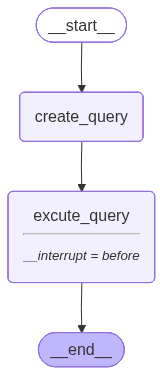

In [23]:
agent = builder.compile(checkpointer=memory , interrupt_before=["excute_query"] )
agent

In [7]:
#Thread and confiaration info 
config = {
    "configurable" : {
        "thread_id" : "1"
    }
}

In [ ]:
for i in agent.stream({"user_query" : "find all the trains from bangalore to mangalore"} ,config=config  , stream_mode='values'):
    print(i)

{'messages': [], 'user_query': 'find all the trains from bangalore to mangalore'}
{'messages': [AIMessage(content=[{'type': 'text', 'text': "SELECT * FROM trains \nWHERE source_station = 'Bangalore' AND destination_station = 'Mangalore';", 'extras': {'signature': 'EooFCocFAQw51sfyDGWpn4T6W84xQu05un3CrYBJqh87tfnrG+6N1j2w6M5x0a6OzTjscz2gsS3utEQF6zqGBpW0UI15cJBJ8vHDP8ze1SxDLmxKuttb4mS3CpaRe3H8iWUqC8iJYsEzX0EbJOCVrMJssl1UWH2PPe7TPIk5RUqBjFrLMyALAeGJw14yztLpBKAqQcVhaKucR5UMlqR43DKEK2OUVWCHB5a2QU39YkjtaR37SXPGIXTUpuNK6ZtsWLr1h1Ue4K5SAoEZgK7ipDAVyn4zbQuhBpO1DJvPVOVzYn7+vCZHRpAJZ2ghMk+fJlqgjKabh5xwkQ6HZii9Ln1iUQ+LyqSEe3CRRopXEE+zldCeC9m7+hwUnDfOE8FPnCTiyV5nBSWgS3YZMXBalwEiykk+3LoKPnGgAqKUVqxlb8SCIYF5COu3dofxwF85eajVhFoocISc0TmI13knddLZ3zblSuSd5CDycLXvRidTjM2Pu7lZaEkEEPE3/lpBXlsKcYlqhCGizj3Wlf4HPB1Jll5qC6EXHuiyjRDEKHZNrIJxZRd2/kCKm/l0gtaQ7wFoxHfijwZbog8msa4SGrgT+uNZUG75M1yLQ8uePKELB8cF/PMgXNzWwKQp0e8lBsg2amPEN8XUIATs+kE+Bou8t42RESTGKXTqx82D+EFhUXmjyqPt4IEzlgwUsjYFZQDj8uMHXpsBfxL1wPhgr5Ti1Ry5MWm

In [10]:
state = agent.get_state(config)

state.next

('excute_query',)

Ask user premission to continue 

In [11]:
print("The query is : ")
print(state.values['query'][0]['text'])


The query is : 
SELECT * FROM trains 
WHERE source_station = 'Bangalore' AND destination_station = 'Mangalore';


In [19]:
choice = input("Press Proceed or Cancel : ")
if choice.lower() ==   'proceed':
    for i in agent.stream(None , config=config , stream_mode='values'):
        print(i['messages'][-1].pretty_print())
else :
    pass 

================================== Ai Message ==================================

[{'type': 'text', 'text': "SELECT * FROM trains \nWHERE source_station = 'Bangalore' AND destination_station = 'Mangalore';", 'extras': {'signature': 'EooFCocFAQw51sfyDGWpn4T6W84xQu05un3CrYBJqh87tfnrG+6N1j2w6M5x0a6OzTjscz2gsS3utEQF6zqGBpW0UI15cJBJ8vHDP8ze1SxDLmxKuttb4mS3CpaRe3H8iWUqC8iJYsEzX0EbJOCVrMJssl1UWH2PPe7TPIk5RUqBjFrLMyALAeGJw14yztLpBKAqQcVhaKucR5UMlqR43DKEK2OUVWCHB5a2QU39YkjtaR37SXPGIXTUpuNK6ZtsWLr1h1Ue4K5SAoEZgK7ipDAVyn4zbQuhBpO1DJvPVOVzYn7+vCZHRpAJZ2ghMk+fJlqgjKabh5xwkQ6HZii9Ln1iUQ+LyqSEe3CRRopXEE+zldCeC9m7+hwUnDfOE8FPnCTiyV5nBSWgS3YZMXBalwEiykk+3LoKPnGgAqKUVqxlb8SCIYF5COu3dofxwF85eajVhFoocISc0TmI13knddLZ3zblSuSd5CDycLXvRidTjM2Pu7lZaEkEEPE3/lpBXlsKcYlqhCGizj3Wlf4HPB1Jll5qC6EXHuiyjRDEKHZNrIJxZRd2/kCKm/l0gtaQ7wFoxHfijwZbog8msa4SGrgT+uNZUG75M1yLQ8uePKELB8cF/PMgXNzWwKQp0e8lBsg2amPEN8XUIATs+kE+Bou8t42RESTGKXTqx82D+EFhUXmjyqPt4IEzlgwUsjYFZQDj8uMHXpsBfxL1wPhgr5Ti1Ry5MWmu7ph9xzrUvsjuTcjpY7ufN7Hs+hLScTw

In [20]:
state =  agent.get_state(config=config)

In [21]:
state.next

()